In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({"figure.dpi": 150, "font.size": 9})

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "processed"
FIG_DIR       = PROJECT_ROOT / "figures" / "detection"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TOPOLOGIES = ["dfn", "dumbbell", "tree"]
SCENARIOS  = ["normal", "ifa", "cp"]

SCENARIO_COLORS = {
    "normal": "#4c72b0",
    "ifa":    "#c44e52",
    "cp":     "#dd8452"
}
ROLE_COLORS = {
    "router":   "#dd8452",
    "consumer": "#4c72b0"
}

# IFA: interests flood to /evil, never satisfied → sat drops, timeout spikes, interests spike
# CP:  junk interests flood /ndn/junk, ARE satisfied → sat increases, cache_hit drops, interests increase moderately
IFA_FEATURES   = ["satisfaction_ratio", "timeout_ratio", "InInterests"]
CP_FEATURES    = ["cache_hit_ratio", "InInterests"]

IFA_DIRECTIONS = {
    "satisfaction_ratio": "down",   # drops during IFA
    "timeout_ratio":      "up",     # spikes during IFA
    "InInterests":        "up",     # spikes during IFA
}
CP_DIRECTIONS = {
    "cache_hit_ratio": "down",      # drops as cache gets polluted
    "InInterests":     "up",        # moderate increase from junk streams
}

# Detection parameters
BASELINE_WINDOW  = 200   # seconds — from pure normal scenario only
IFA_Z_THRESH     = 2.5
CP_Z_THRESH      = 2.0
IFA_PERSIST      = 3     # 3 consecutive steps
CP_PERSIST_FRAC  = 0.3   # 30% of last 10 steps
CP_WINDOW        = 10
ALARM_THRESHOLD  = 50
ATTACK_START     = 301

print("Config ready.")
print(f"IFA features : {IFA_FEATURES}")
print(f"CP  features : {CP_FEATURES}")
print(f"Attack start : t >= {ATTACK_START}")

Config ready.
IFA features : ['satisfaction_ratio', 'timeout_ratio', 'InInterests']
CP  features : ['cache_hit_ratio', 'InInterests']
Attack start : t >= 301


In [2]:
full        = pd.read_csv(PROCESSED_DIR / "full_dataset.csv")
train_normal = pd.read_csv(PROCESSED_DIR / "train_normal.csv")

print(f"Full dataset  : {full.shape}")
print(f"Train normal  : {train_normal.shape}")
print(f"\nTopologies : {full['topology'].unique().tolist()}")
print(f"Scenarios  : {full['scenario'].unique().tolist()}")
print(f"Time range : {full['Time'].min()} → {full['Time'].max()}")
print(f"\nNode roles per topology:")
for topo in TOPOLOGIES:
    df_t = full[full["topology"]==topo]
    consumers = sorted(df_t[df_t["role"]=="consumer"]["Node"].unique())
    routers   = sorted(df_t[df_t["role"]=="router"]["Node"].unique())
    print(f"  {topo}: consumers={consumers}, routers={routers}")

Full dataset  : (60918, 25)
Train normal  : (20366, 25)

Topologies : ['dfn', 'dumbbell', 'tree']
Scenarios  : ['normal', 'ifa', 'cp']
Time range : 1 → 599

Node roles per topology:
  dfn: consumers=[np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)], routers=[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
  dumbbell: consumers=[np.int64(0), np.int64(1), np.int64(2)], routers=[np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
  tree: consumers=[np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)], routers=[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [3]:
def compute_baselines(train_normal, topologies, baseline_window=BASELINE_WINDOW):
    """
    Compute per-node baseline stats from pure normal scenario files only.
    Uses first baseline_window seconds.
    Returns dict keyed by (topo, node) with mean/std per feature.
    """
    all_features = list(set(IFA_FEATURES + CP_FEATURES))
    baselines = {}

    for topo in topologies:
        df_topo = train_normal[
            (train_normal["topology"] == topo) &
            (train_normal["Time"] <= baseline_window)
        ]

        for node in df_topo["Node"].unique():
            node_data = df_topo[df_topo["Node"] == node]
            role      = node_data["role"].iloc[0]

            stats = {}
            for feat in all_features:
                mu    = node_data[feat].mean()
                sigma = node_data[feat].std()
                sigma = max(sigma, 1e-9)
                stats[feat] = {"mu": mu, "sigma": sigma}

            baselines[(topo, node)] = {"role": role, "stats": stats}

    print(f"Built baselines for {len(baselines)} (topo, node) pairs")
    return baselines

baselines_global = compute_baselines(train_normal, TOPOLOGIES)

# Quick sanity check
print("\nSample baseline (dfn, node 0):")
b = baselines_global[("dfn", 0)]
for feat, vals in b["stats"].items():
    print(f"  {feat:<25} mu={vals['mu']:.4f}  sigma={vals['sigma']:.4f}")

Built baselines for 34 (topo, node) pairs

Sample baseline (dfn, node 0):
  timeout_ratio             mu=0.7050  sigma=0.4572
  satisfaction_ratio        mu=1.0000  sigma=0.0000
  cache_hit_ratio           mu=0.0000  sigma=0.0000
  InInterests               mu=0.5000  sigma=2.8981


In [4]:
def directional_z(series, mu, sigma, direction):
    """
    Compute one-sided or two-sided z-score based on direction.
    direction='down' → flag only drops below baseline
    direction='up'   → flag only spikes above baseline
    direction='both' → flag any deviation
    """
    z = (series - mu) / sigma
    if direction == "down":
        return (-z).clip(lower=0)
    elif direction == "up":
        return z.clip(lower=0)
    else:
        return z.abs()


def run_detector(df_input, baselines,
                 ifa_z=IFA_Z_THRESH, cp_z=CP_Z_THRESH,
                 ifa_persist=IFA_PERSIST,
                 cp_window=CP_WINDOW, cp_frac=CP_PERSIST_FRAC):
    """
    Dual detector: separate IFA and CP detectors per node.
    IFA detector: persistent z-score on IFA_FEATURES
    CP detector:  fractional z-score on CP_FEATURES over rolling window
    Final anomaly_score = max(ifa_score, cp_score)
    """
    results = []
    missing = []

    for topo in df_input["topology"].unique():
        for node in df_input[df_input["topology"]==topo]["Node"].unique():
            key = (topo, node)
            if key not in baselines:
                missing.append(key)
                continue

            stats = baselines[key]["stats"]

            for scenario in df_input["scenario"].unique():
                node_data = df_input[
                    (df_input["topology"] == topo) &
                    (df_input["Node"] == node) &
                    (df_input["scenario"] == scenario)
                ].sort_values("Time").copy()

                if len(node_data) < 5:
                    continue

                # ── IFA detector ──────────────────────────────────────────
                z_ifa = pd.DataFrame(index=node_data.index)
                for feat in IFA_FEATURES:
                    mu    = stats[feat]["mu"]
                    sigma = stats[feat]["sigma"]
                    z_ifa[feat] = directional_z(
                        node_data[feat], mu, sigma,
                        IFA_DIRECTIONS[feat])

                node_data["z_ifa"]   = z_ifa.mean(axis=1)
                flagged_ifa          = (node_data["z_ifa"] > ifa_z).astype(int)
                node_data["ifa_score"] = (
                    flagged_ifa
                    .rolling(ifa_persist, min_periods=1).sum() / ifa_persist
                    * 100
                ).clip(0, 100)

                # ── CP detector ───────────────────────────────────────────
                z_cp = pd.DataFrame(index=node_data.index)
                for feat in CP_FEATURES:
                    mu    = stats[feat]["mu"]
                    sigma = stats[feat]["sigma"]
                    z_cp[feat] = directional_z(
                        node_data[feat], mu, sigma,
                        CP_DIRECTIONS[feat])

                node_data["z_cp"]   = z_cp.mean(axis=1)
                flagged_cp          = (node_data["z_cp"] > cp_z).astype(int)
                node_data["cp_score"] = (
                    flagged_cp
                    .rolling(cp_window, min_periods=1).sum() / cp_window
                    * 100
                ).clip(0, 100)

                # ── Combined score ────────────────────────────────────────
                node_data["anomaly_score"] = np.maximum(
                    node_data["ifa_score"],
                    node_data["cp_score"]
                )

                results.append(node_data)

    if missing:
        print(f"WARNING: no baseline for {len(missing)} pairs: {missing[:5]}")

    return pd.concat(results, ignore_index=True)


print("Detector defined.")
print(f"  IFA: features={IFA_FEATURES}, z>{IFA_Z_THRESH}, persist={IFA_PERSIST} steps")
print(f"  CP : features={CP_FEATURES}, z>{CP_Z_THRESH}, {CP_PERSIST_FRAC*100:.0f}% of {CP_WINDOW} steps")

Detector defined.
  IFA: features=['satisfaction_ratio', 'timeout_ratio', 'InInterests'], z>2.5, persist=3 steps
  CP : features=['cache_hit_ratio', 'InInterests'], z>2.0, 30% of 10 steps


In [5]:
print("Running global model (baseline from all normal scenarios)...")
full_scored = run_detector(full, baselines_global)
full_scored["model"] = "global"

print(f"Scored dataset: {full_scored.shape}")

print("\nAnomaly score by scenario:")
print(full_scored.groupby("scenario")["anomaly_score"].describe().round(2))

print("\nIFA score by scenario:")
print(full_scored.groupby("scenario")["ifa_score"].describe().round(2))

print("\nCP score by scenario:")
print(full_scored.groupby("scenario")["cp_score"].describe().round(2))

print(f"\nBefore/after t={ATTACK_START}:")
print(f"{'Topology-Attack':<20} {'IFA pre':>8} {'IFA post':>10} "
      f"{'CP pre':>8} {'CP post':>10} {'Anom pre':>10} {'Anom post':>11}")
print("-" * 82)
for topo in TOPOLOGIES:
    for attack in ["ifa", "cp"]:
        g = full_scored[
            (full_scored["topology"]==topo) &
            (full_scored["scenario"]==attack)
        ]
        pre  = g[g["Time"] <  ATTACK_START]
        post = g[g["Time"] >= ATTACK_START]
        print(f"{topo}-{attack:<15} "
              f"{pre['ifa_score'].mean():>8.1f} "
              f"{post['ifa_score'].mean():>10.1f} "
              f"{pre['cp_score'].mean():>8.1f} "
              f"{post['cp_score'].mean():>10.1f} "
              f"{pre['anomaly_score'].mean():>10.1f} "
              f"{post['anomaly_score'].mean():>11.1f}")

Running global model (baseline from all normal scenarios)...


Scored dataset: (60918, 31)

Anomaly score by scenario:
            count   mean    std  min  25%  50%    75%    max
scenario                                                    
cp        20186.0  34.04  46.40  0.0  0.0  0.0  100.0  100.0
ifa       20366.0  27.45  43.72  0.0  0.0  0.0  100.0  100.0
normal    20366.0   5.21  20.29  0.0  0.0  0.0    0.0  100.0

IFA score by scenario:
            count   mean    std  min  25%  50%    75%    max
scenario                                                    
cp        20186.0  33.36  46.62  0.0  0.0  0.0  100.0  100.0
ifa       20366.0  26.98  43.86  0.0  0.0  0.0  100.0  100.0
normal    20366.0   4.75  20.08  0.0  0.0  0.0    0.0  100.0

CP score by scenario:
            count   mean    std  min  25%  50%    75%    max
scenario                                                    
cp        20186.0  30.56  44.94  0.0  0.0  0.0  100.0  100.0
ifa       20366.0  20.96  40.05  0.0  0.0  0.0    0.0  100.0
normal    20366.0   0.50   3.68  0.0  0.0  

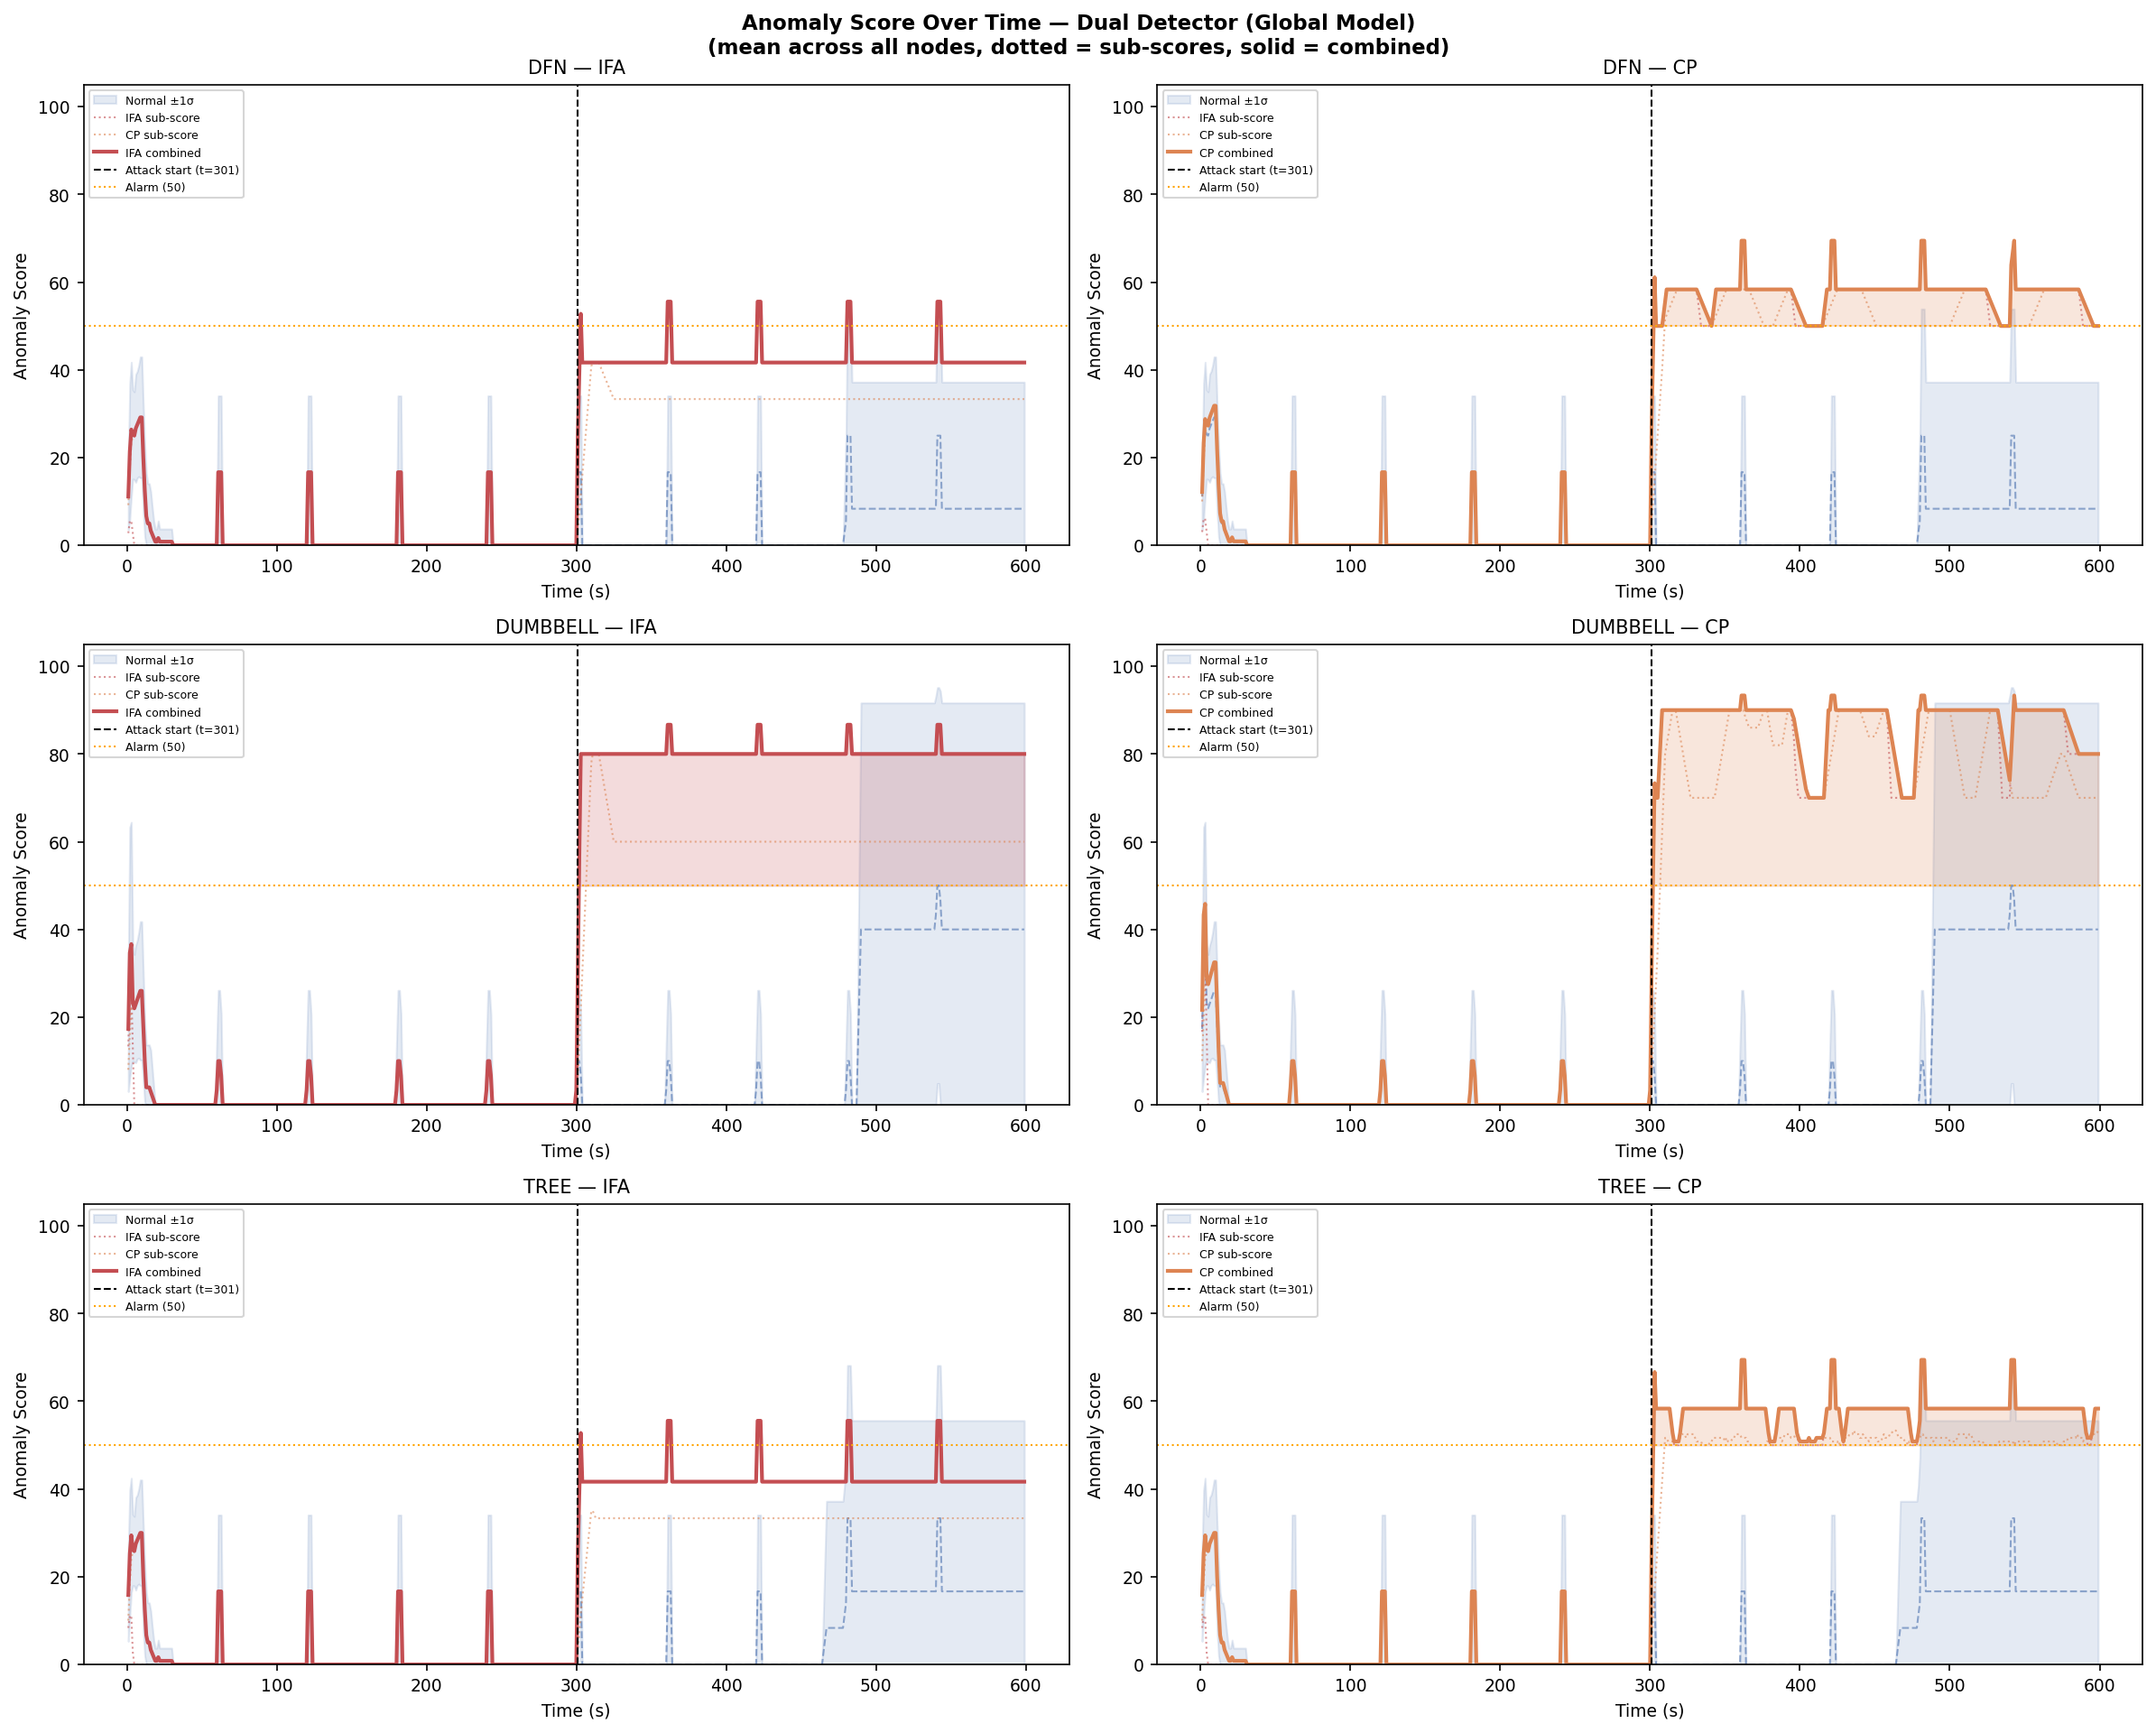

Saved fig_score_timeseries.png


In [6]:
fig, axes = plt.subplots(3, 2, figsize=(16, 13))

for row, topo in enumerate(TOPOLOGIES):
    for col, attack in enumerate(["ifa", "cp"]):
        ax = axes[row][col]

        # Normal baseline band
        norm_grp  = full_scored[
            (full_scored["topology"]==topo) &
            (full_scored["scenario"]=="normal")
        ].groupby("Time")["anomaly_score"]
        norm_mean = norm_grp.mean()
        norm_std  = norm_grp.std().fillna(0)

        ax.fill_between(
            norm_mean.index,
            (norm_mean - norm_std).clip(0),
            (norm_mean + norm_std).clip(0, 100),
            alpha=0.15, color=SCENARIO_COLORS["normal"],
            label="Normal ±1σ")
        ax.plot(norm_mean.index, norm_mean.values,
                color=SCENARIO_COLORS["normal"],
                linewidth=1.0, linestyle="--", alpha=0.6)

        # Attack combined score
        atk_ts = full_scored[
            (full_scored["topology"]==topo) &
            (full_scored["scenario"]==attack)
        ].groupby("Time")["anomaly_score"].mean()

        # IFA sub-score and CP sub-score
        ifa_ts = full_scored[
            (full_scored["topology"]==topo) &
            (full_scored["scenario"]==attack)
        ].groupby("Time")["ifa_score"].mean()

        cp_ts = full_scored[
            (full_scored["topology"]==topo) &
            (full_scored["scenario"]==attack)
        ].groupby("Time")["cp_score"].mean()

        ax.plot(ifa_ts.index, ifa_ts.values,
                color="#c44e52", linewidth=1.0,
                linestyle=":", alpha=0.6, label="IFA sub-score")
        ax.plot(cp_ts.index, cp_ts.values,
                color="#dd8452", linewidth=1.0,
                linestyle=":", alpha=0.6, label="CP sub-score")
        ax.plot(atk_ts.index, atk_ts.values,
                color=SCENARIO_COLORS[attack],
                linewidth=2.0, label=f"{attack.upper()} combined")

        ax.axvline(ATTACK_START, color="black", linestyle="--",
                   linewidth=1.0, label=f"Attack start (t={ATTACK_START})")
        ax.axhline(ALARM_THRESHOLD, color="orange", linestyle=":",
                   linewidth=1.0, label=f"Alarm ({ALARM_THRESHOLD})")
        ax.fill_between(
            atk_ts.index, atk_ts.values, ALARM_THRESHOLD,
            where=(atk_ts.values > ALARM_THRESHOLD),
            alpha=0.2, color=SCENARIO_COLORS[attack])

        ax.set_title(f"{topo.upper()} — {attack.upper()}", fontsize=10)
        ax.set_ylim(0, 105)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Anomaly Score")
        ax.legend(fontsize=6, loc="upper left")

fig.suptitle(
    "Anomaly Score Over Time — Dual Detector (Global Model)\n"
    "(mean across all nodes, dotted = sub-scores, solid = combined)",
    fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_score_timeseries.png", bbox_inches="tight")
plt.show()
print("Saved fig_score_timeseries.png")

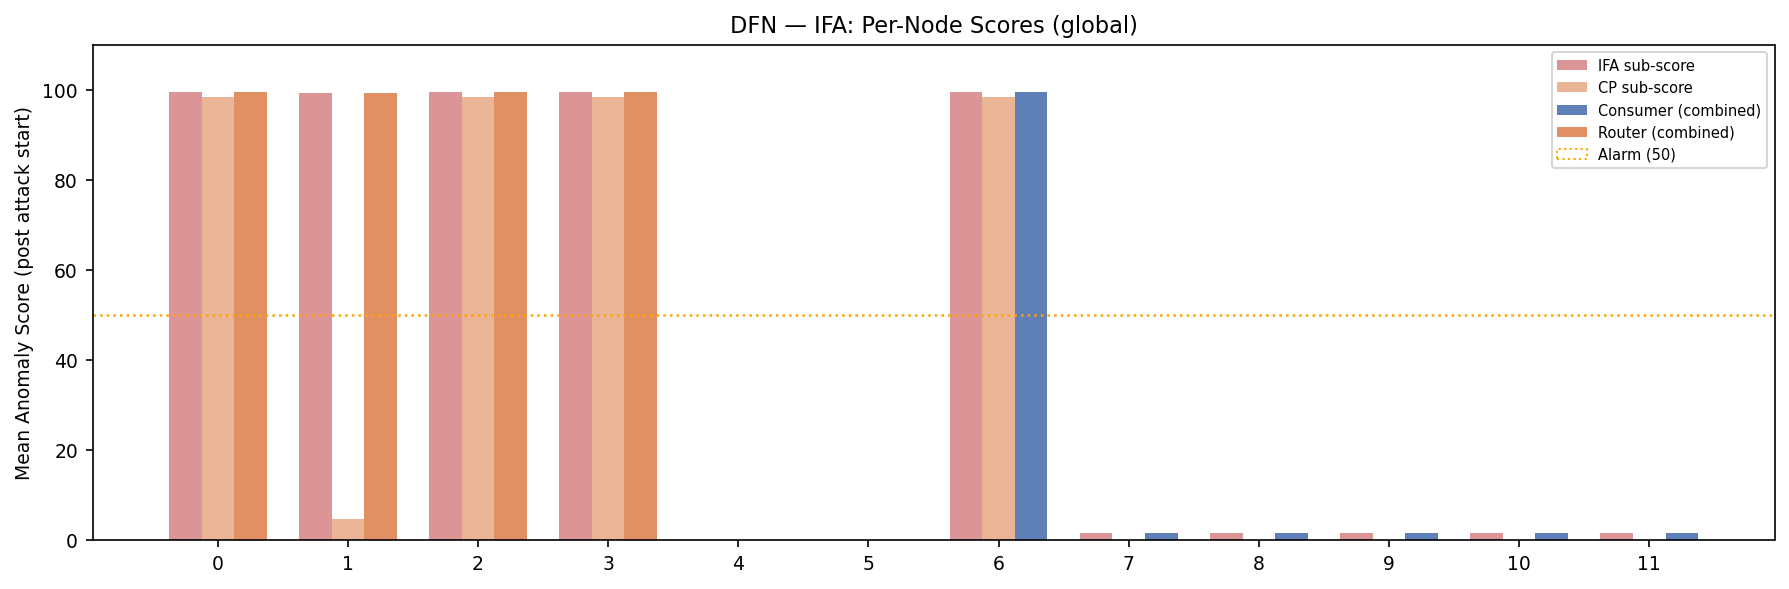

Saved fig_pernode_dfn_ifa_global.png


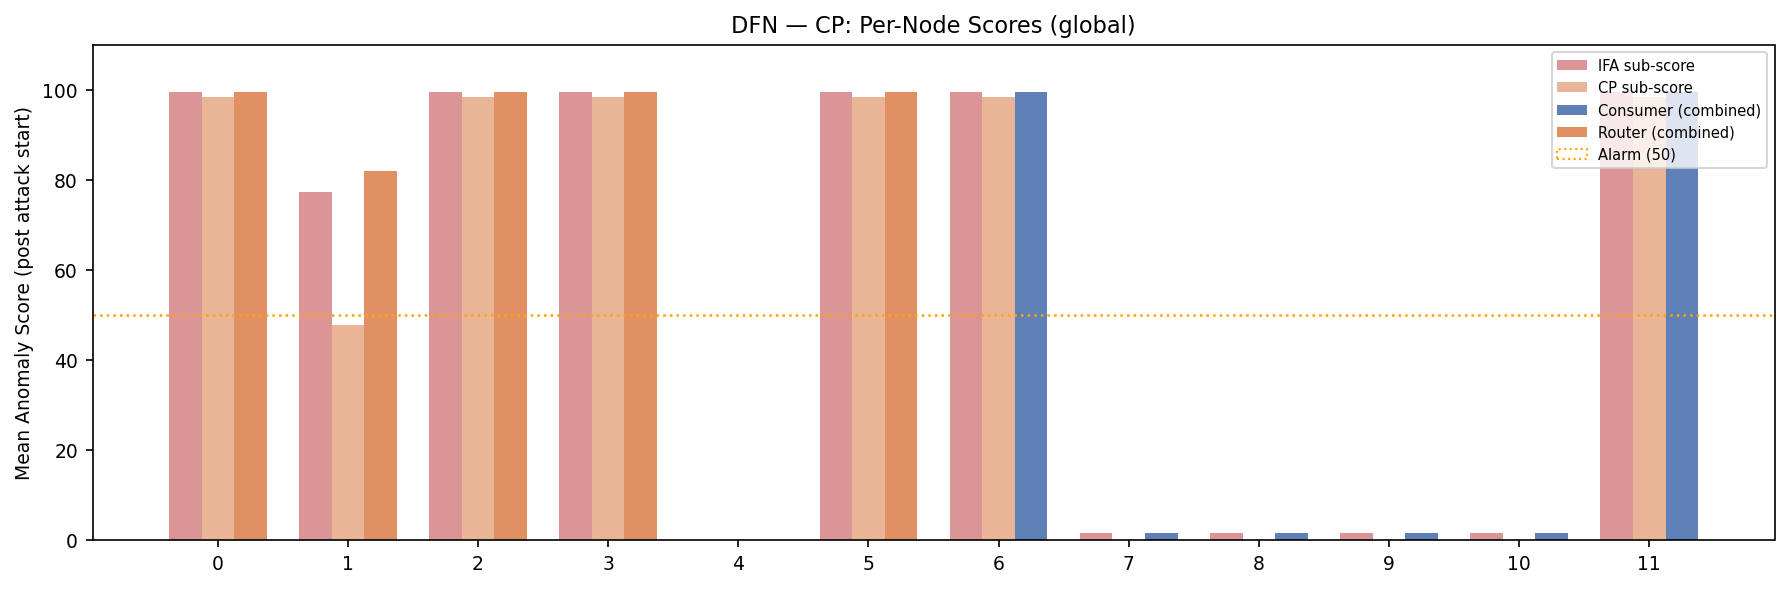

Saved fig_pernode_dfn_cp_global.png


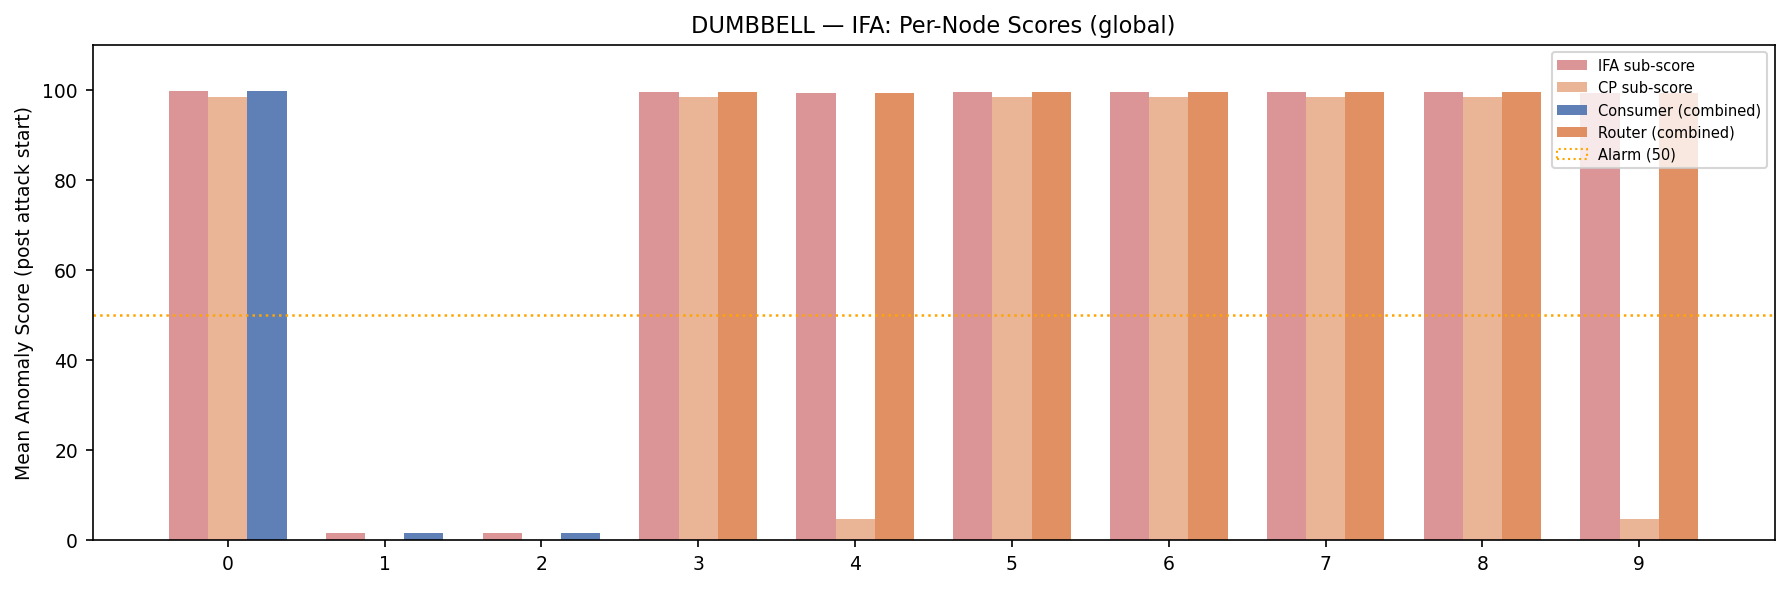

Saved fig_pernode_dumbbell_ifa_global.png


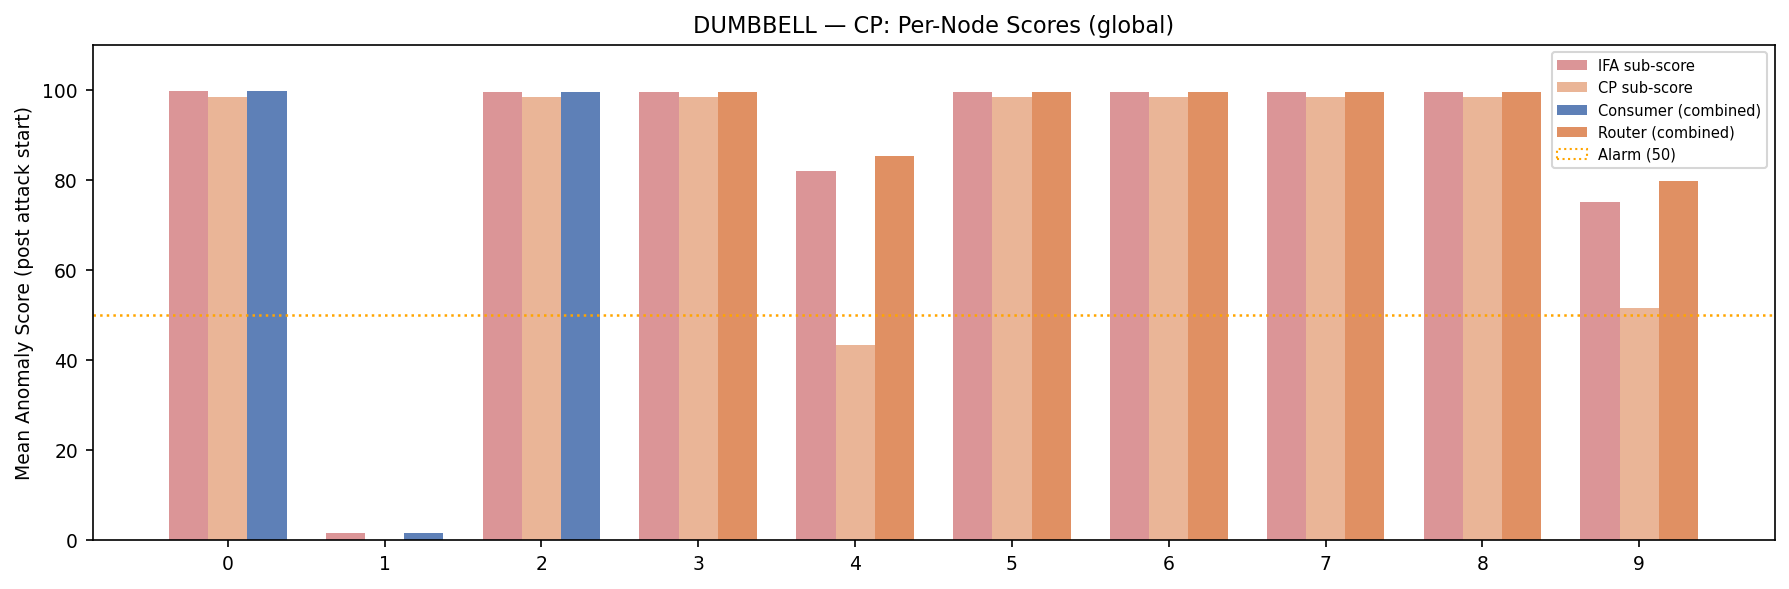

Saved fig_pernode_dumbbell_cp_global.png


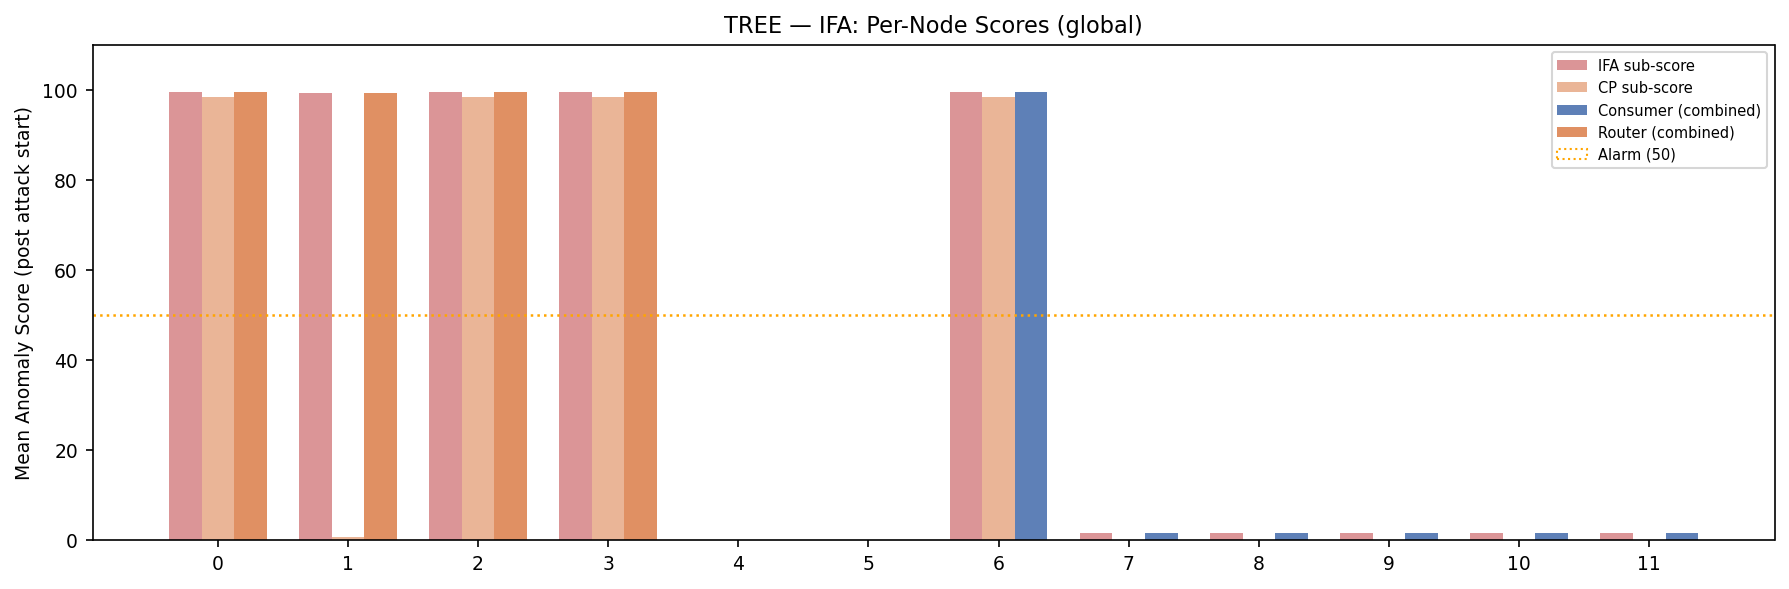

Saved fig_pernode_tree_ifa_global.png


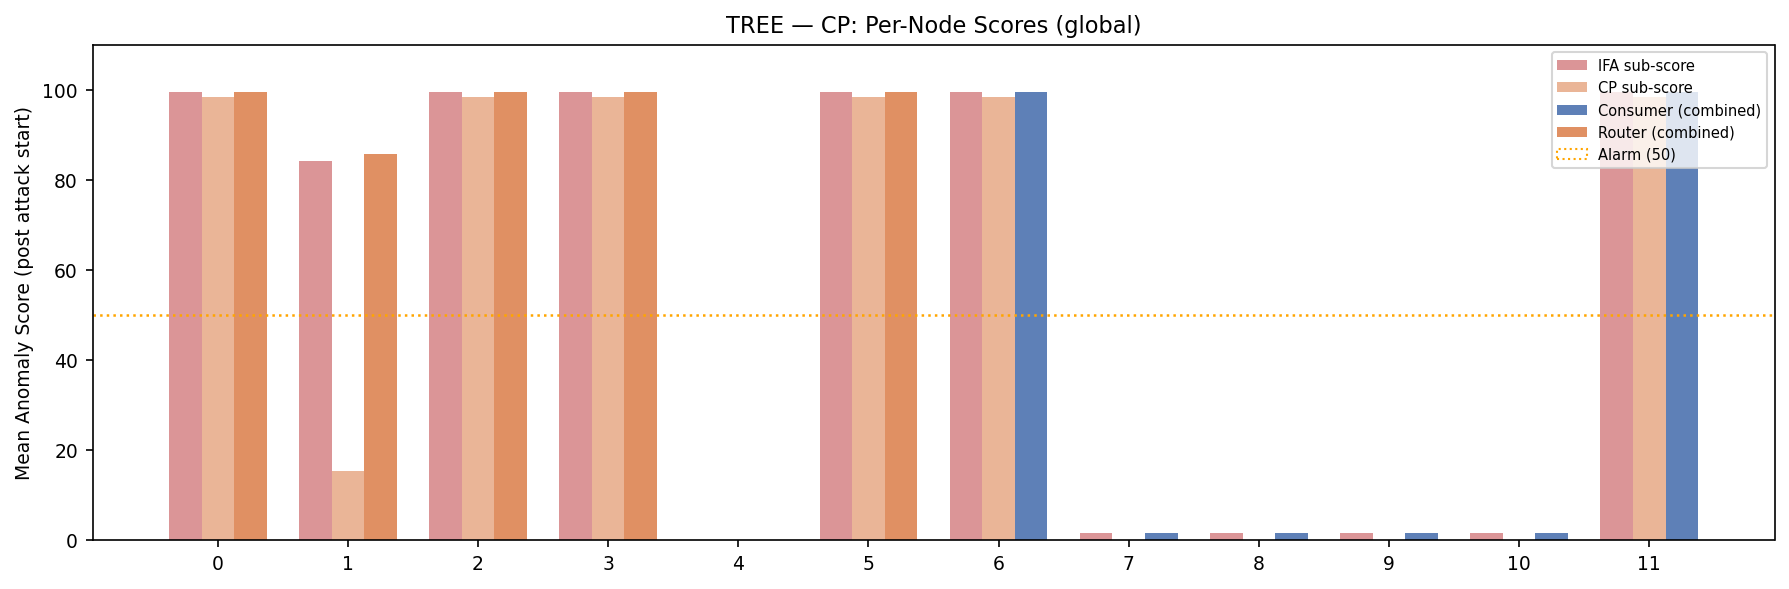

Saved fig_pernode_tree_cp_global.png


In [7]:
def plot_pernode_scores(topo, attack, scored_df, model_name=""):
    grp = scored_df[
        (scored_df["topology"]==topo) &
        (scored_df["scenario"]==attack) &
        (scored_df["Time"] >= ATTACK_START)
    ]
    nodes       = sorted(grp["Node"].unique())
    roles       = scored_df[scored_df["topology"]==topo].groupby("Node")["role"].first()
    anom_scores = grp.groupby("Node")["anomaly_score"].mean()
    ifa_scores  = grp.groupby("Node")["ifa_score"].mean()
    cp_scores   = grp.groupby("Node")["cp_score"].mean()

    x     = np.arange(len(nodes))
    width = 0.25

    fig, ax = plt.subplots(figsize=(12, 4))
    colors = [ROLE_COLORS[roles[n]] for n in nodes]

    ax.bar(x - width, [ifa_scores.get(n, 0) for n in nodes],
           width, color="#c44e52", alpha=0.6, label="IFA sub-score")
    ax.bar(x,         [cp_scores.get(n, 0) for n in nodes],
           width, color="#dd8452", alpha=0.6, label="CP sub-score")
    ax.bar(x + width, [anom_scores.get(n, 0) for n in nodes],
           width, color=colors, alpha=0.9, label="Combined")

    ax.axhline(ALARM_THRESHOLD, color="orange", linestyle=":",
               linewidth=1.2, label=f"Alarm ({ALARM_THRESHOLD})")
    ax.set_xticks(x)
    ax.set_xticklabels(nodes, fontsize=9)
    ax.set_ylim(0, 110)
    ax.set_ylabel("Mean Anomaly Score (post attack start)")
    ax.set_title(
        f"{topo.upper()} — {attack.upper()}: Per-Node Scores "
        f"({'Global' if not model_name else model_name})")

    legend_handles = [
        Patch(facecolor="#c44e52", alpha=0.6, label="IFA sub-score"),
        Patch(facecolor="#dd8452", alpha=0.6, label="CP sub-score"),
        Patch(facecolor=ROLE_COLORS["consumer"], alpha=0.9, label="Consumer (combined)"),
        Patch(facecolor=ROLE_COLORS["router"],   alpha=0.9, label="Router (combined)"),
        Patch(facecolor="none", edgecolor="orange",
              linestyle=":", label=f"Alarm ({ALARM_THRESHOLD})"),
    ]
    ax.legend(handles=legend_handles, fontsize=7, loc="upper right")
    plt.tight_layout()
    fname = FIG_DIR / f"fig_pernode_{topo}_{attack}_{model_name or 'global'}.png"
    plt.savefig(fname, bbox_inches="tight")
    plt.show()
    print(f"Saved {fname.name}")

for topo in TOPOLOGIES:
    for attack in ["ifa", "cp"]:
        plot_pernode_scores(topo, attack, full_scored, "global")

In [8]:
latency_rows = []

for topo in TOPOLOGIES:
    for attack in ["ifa", "cp"]:
        for node in full_scored[full_scored["topology"]==topo]["Node"].unique():
            grp = full_scored[
                (full_scored["topology"]==topo) &
                (full_scored["scenario"]==attack) &
                (full_scored["Node"]==node)
            ].sort_values("Time")

            post        = grp[grp["Time"] >= ATTACK_START]
            alarm_times = post[post["anomaly_score"] > ALARM_THRESHOLD]["Time"]
            role        = grp["role"].iloc[0] if len(grp) > 0 else "unknown"

            if len(alarm_times) > 0:
                latency  = int(alarm_times.iloc[0]) - ATTACK_START
                detected = True
            else:
                latency  = None
                detected = False

            latency_rows.append({
                "topology": topo, "attack": attack,
                "node": node, "role": role,
                "detected": detected, "latency_s": latency
            })

df_latency = pd.DataFrame(latency_rows)
df_latency.to_csv(PROCESSED_DIR / "detection_latency.csv", index=False)

print("Detection rate and mean latency (Global Model):")
summary = df_latency.groupby(["topology","attack"]).agg(
    detection_rate = ("detected", "mean"),
    mean_latency_s = ("latency_s", "mean"),
    min_latency_s  = ("latency_s", "min"),
    nodes_detected = ("detected", "sum"),
    total_nodes    = ("detected", "count")
).round(2)
print(summary.to_string())
print("\nSaved detection_latency.csv")

Detection rate and mean latency (Global Model):
                 detection_rate  mean_latency_s  min_latency_s  nodes_detected  total_nodes
topology attack                                                                            
dfn      cp                0.58            2.14            1.0               7           12
         ifa               0.42            1.20            1.0               5           12
dumbbell cp                0.90            2.00            0.0               9           10
         ifa               0.80            1.12            0.0               8           10
tree     cp                0.58            1.14            1.0               7           12
         ifa               0.42            1.20            1.0               5           12

Saved detection_latency.csv


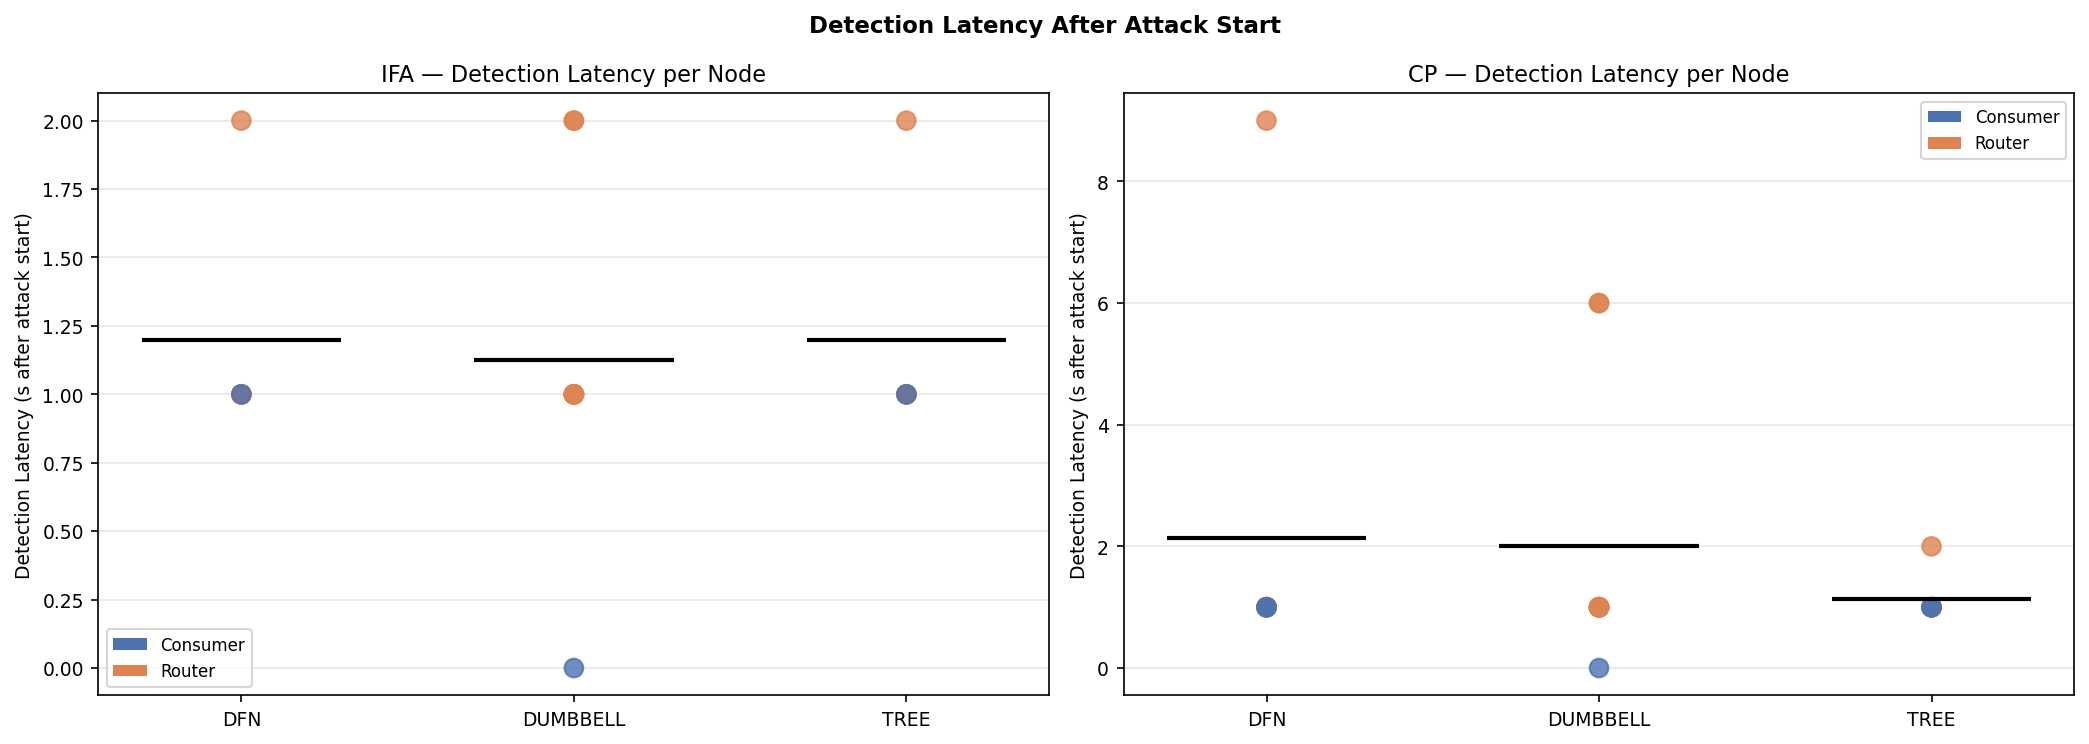

Saved fig_detection_latency.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for col, attack in enumerate(["ifa", "cp"]):
    ax = axes[col]
    df_atk = df_latency[df_latency["attack"]==attack]

    for ti, topo in enumerate(TOPOLOGIES):
        df_t = df_atk[
            (df_atk["topology"]==topo) &
            (df_atk["detected"]==True)
        ]
        if df_t.empty:
            continue
        ax.scatter(
            [ti] * len(df_t),
            df_t["latency_s"],
            c=[ROLE_COLORS[r] for r in df_t["role"]],
            s=80, alpha=0.8, zorder=3)
        ax.hlines(
            df_t["latency_s"].mean(),
            ti - 0.3, ti + 0.3,
            colors="black", linewidth=2, zorder=4)

    ax.set_xticks(range(len(TOPOLOGIES)))
    ax.set_xticklabels([t.upper() for t in TOPOLOGIES])
    ax.set_ylabel("Detection Latency (s after attack start)")
    ax.set_title(f"{attack.upper()} — Detection Latency per Node")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(
        handles=[
            Patch(facecolor=ROLE_COLORS["consumer"], label="Consumer"),
            Patch(facecolor=ROLE_COLORS["router"],   label="Router"),
        ], fontsize=8)

plt.suptitle("Detection Latency After Attack Start",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_detection_latency.png", bbox_inches="tight")
plt.show()
print("Saved fig_detection_latency.png")

In [10]:
def compute_pertopo_baselines(train_normal, topo,
                              baseline_window=BASELINE_WINDOW):
    """Same as global but restricted to one topology."""
    return compute_baselines(train_normal, [topo], baseline_window)

print("Running per-topology models...")
pertopo_parts = []

for topo in TOPOLOGIES:
    pt_baselines = compute_pertopo_baselines(train_normal, topo)
    df_t = run_detector(
        full[full["topology"]==topo],
        pt_baselines)
    df_t["model"] = "per_topology"
    pertopo_parts.append(df_t)
    print(f"  {topo}: {df_t.shape[0]} rows scored")

full_pertopo = pd.concat(pertopo_parts, ignore_index=True)

print(f"\nBefore/after t={ATTACK_START} — Global vs Per-Topology:")
print(f"{'Topology-Attack':<20} {'G pre':>7} {'G post':>8} "
      f"{'PT pre':>8} {'PT post':>9} {'G lift':>7} {'PT lift':>8}")
print("-" * 72)

for topo in TOPOLOGIES:
    for attack in ["ifa", "cp"]:
        g = full_scored[
            (full_scored["topology"]==topo) &
            (full_scored["scenario"]==attack)]
        p = full_pertopo[
            (full_pertopo["topology"]==topo) &
            (full_pertopo["scenario"]==attack)]

        g_pre  = g[g["Time"] <  ATTACK_START]["anomaly_score"].mean()
        g_post = g[g["Time"] >= ATTACK_START]["anomaly_score"].mean()
        p_pre  = p[p["Time"] <  ATTACK_START]["anomaly_score"].mean()
        p_post = p[p["Time"] >= ATTACK_START]["anomaly_score"].mean()

        print(f"{topo}-{attack:<15} "
              f"{g_pre:>7.1f} {g_post:>8.1f} "
              f"{p_pre:>8.1f} {p_post:>9.1f} "
              f"{g_post-g_pre:>7.1f} {p_post-p_pre:>8.1f}")

Running per-topology models...
Built baselines for 12 (topo, node) pairs
  dfn: 21504 rows scored
Built baselines for 10 (topo, node) pairs


  dumbbell: 17850 rows scored
Built baselines for 12 (topo, node) pairs
  tree: 21564 rows scored

Before/after t=301 — Global vs Per-Topology:
Topology-Attack        G pre   G post   PT pre   PT post  G lift  PT lift
------------------------------------------------------------------------
dfn-ifa                 1.7     42.2      1.7      42.2    40.5     40.5
dfn-cp                  1.8     57.2      1.8      57.2    55.5     55.5
dumbbell-ifa                 1.4     80.0      1.4      80.0    78.6     78.6
dumbbell-cp                  1.5     86.5      1.5      86.5    85.0     85.0
tree-ifa                 1.8     42.2      1.8      42.2    40.4     40.4
tree-cp                  1.8     57.5      1.8      57.5    55.8     55.8


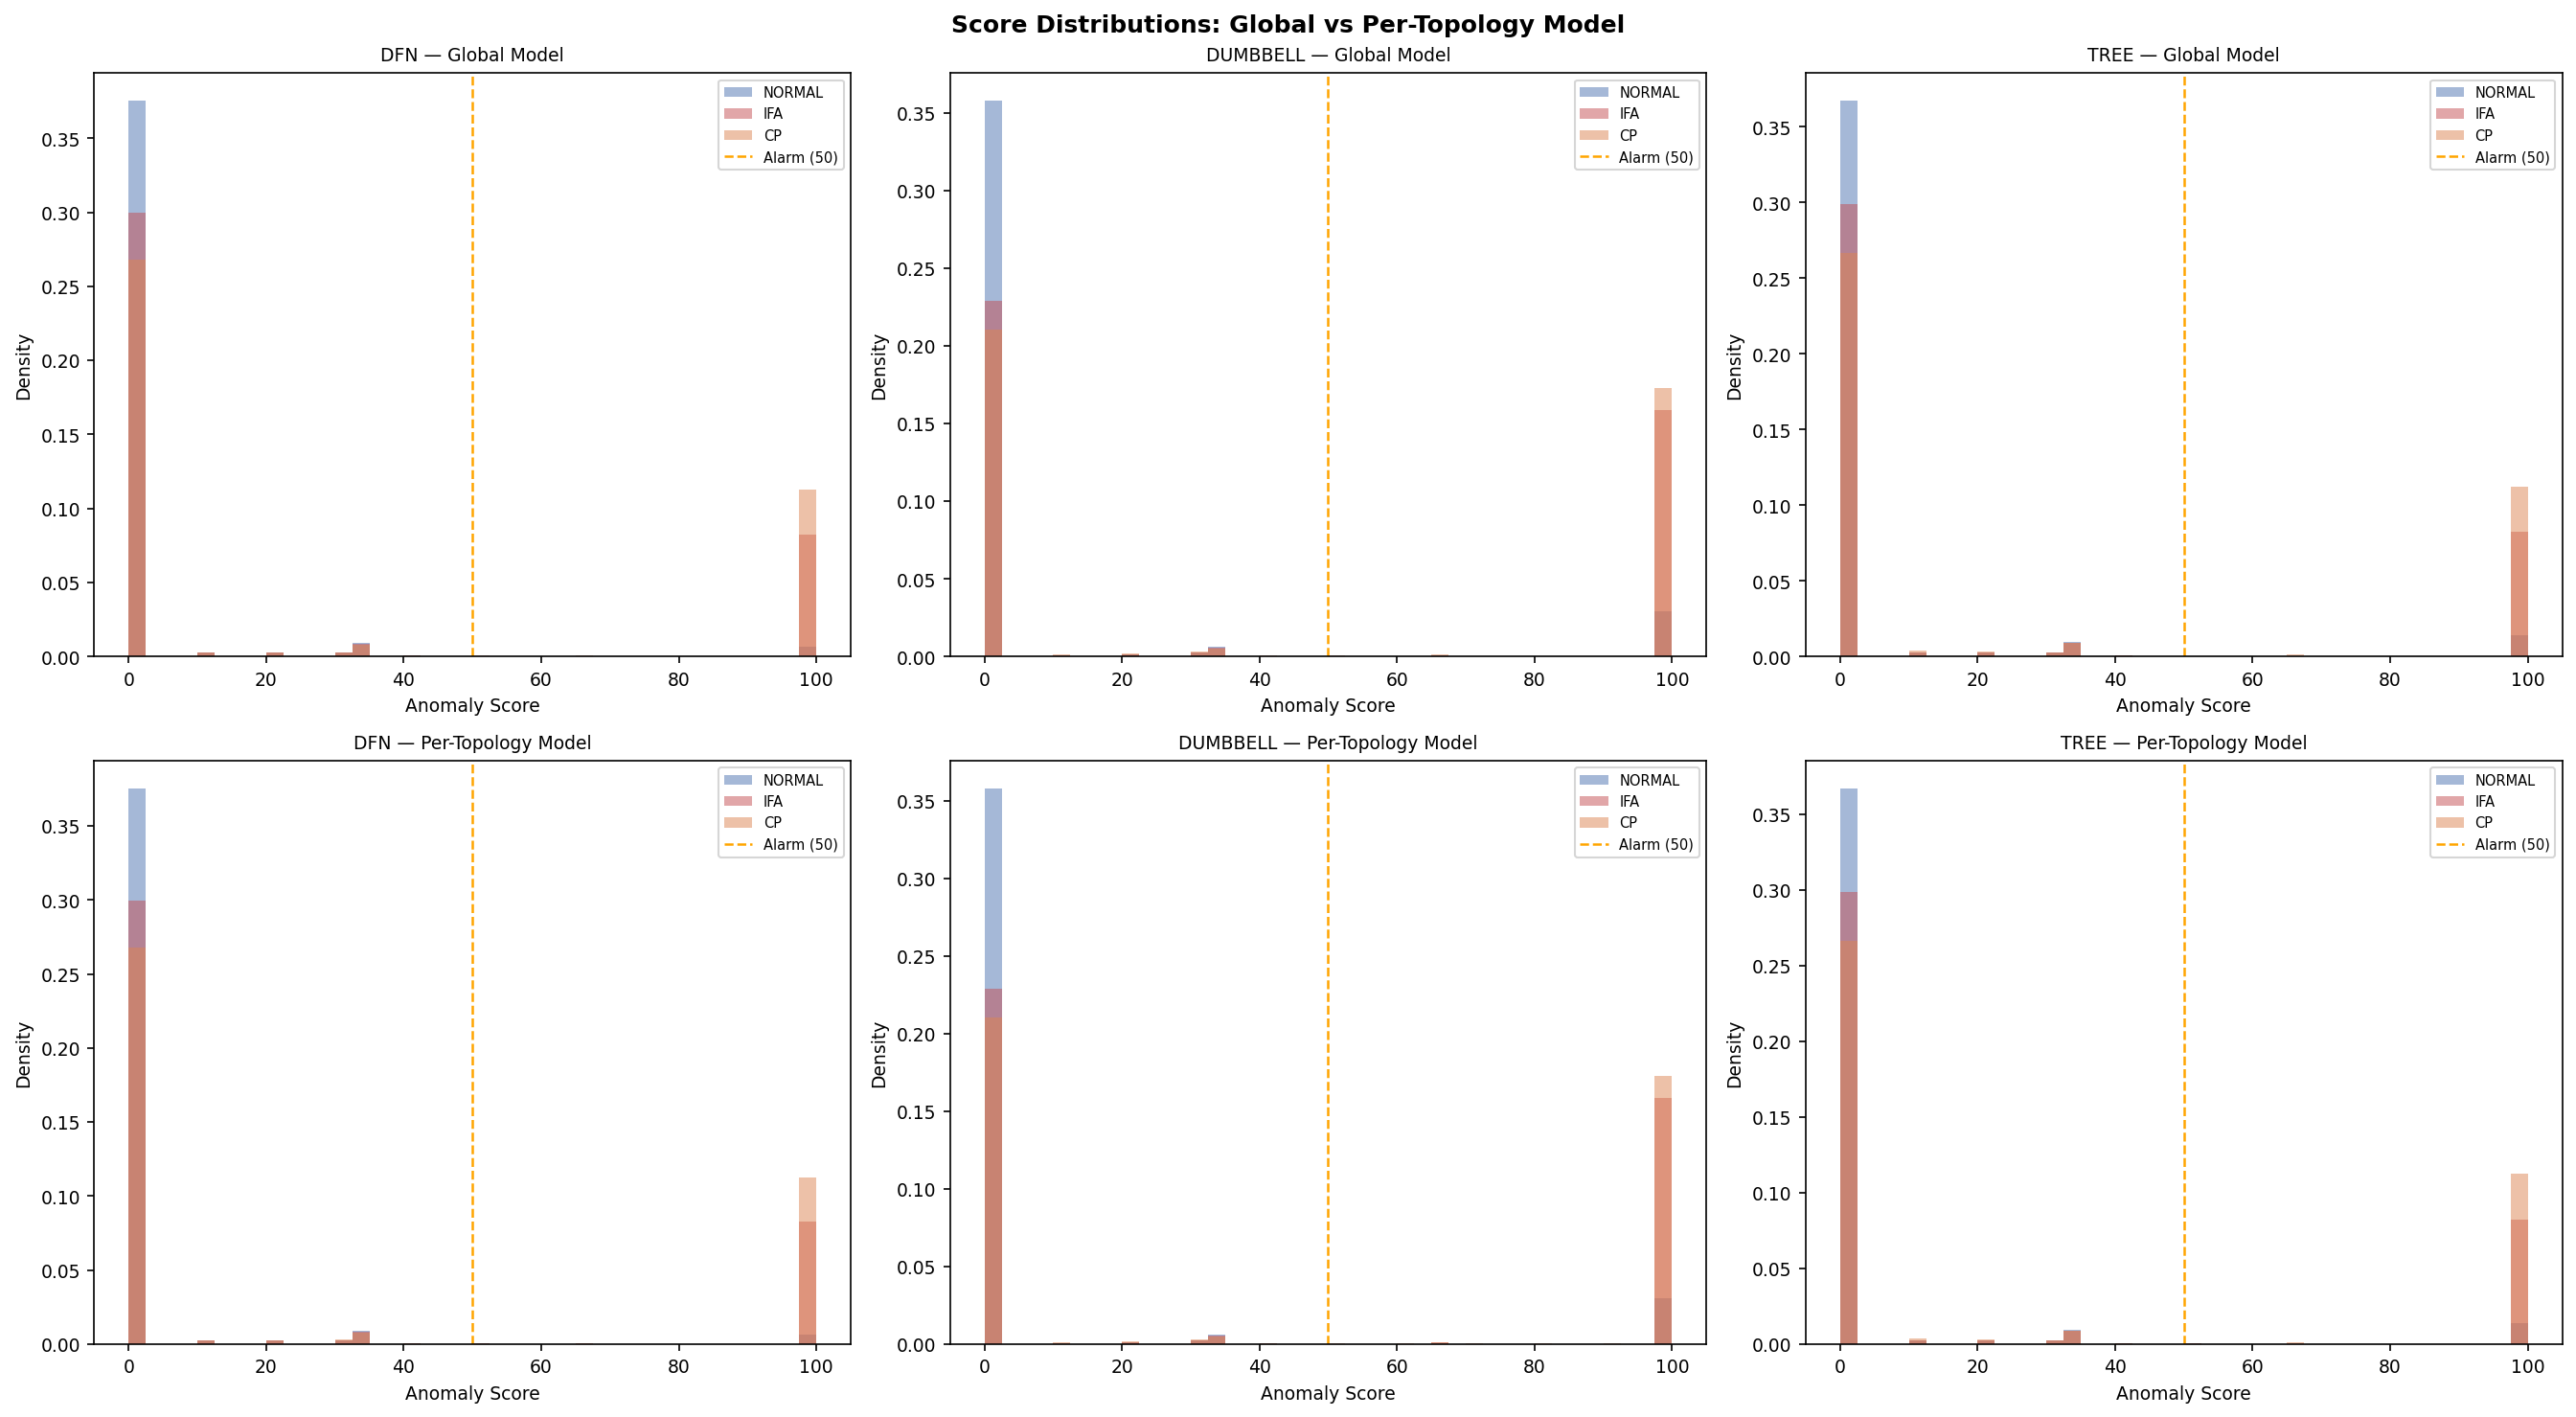

Saved fig_score_dist_comparison.png


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Score Distributions: Global vs Per-Topology Model",
             fontsize=12, fontweight="bold")
bins = np.linspace(0, 100, 41)

for col, topo in enumerate(TOPOLOGIES):
    for row, (scored_df, model_name) in enumerate([
        (full_scored,  "Global Model"),
        (full_pertopo, "Per-Topology Model")
    ]):
        ax = axes[row][col]
        for scenario, color in SCENARIO_COLORS.items():
            vals = scored_df[
                (scored_df["topology"]==topo) &
                (scored_df["scenario"]==scenario)
            ]["anomaly_score"]
            ax.hist(vals, bins=bins, alpha=0.5, color=color,
                    density=True, label=scenario.upper())
        ax.axvline(ALARM_THRESHOLD, color="orange", linestyle="--",
                   linewidth=1.2, label=f"Alarm ({ALARM_THRESHOLD})")
        ax.set_title(f"{topo.upper()} — {model_name}", fontsize=9)
        ax.set_xlabel("Anomaly Score")
        ax.set_ylabel("Density")
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_score_dist_comparison.png", bbox_inches="tight")
plt.show()
print("Saved fig_score_dist_comparison.png")

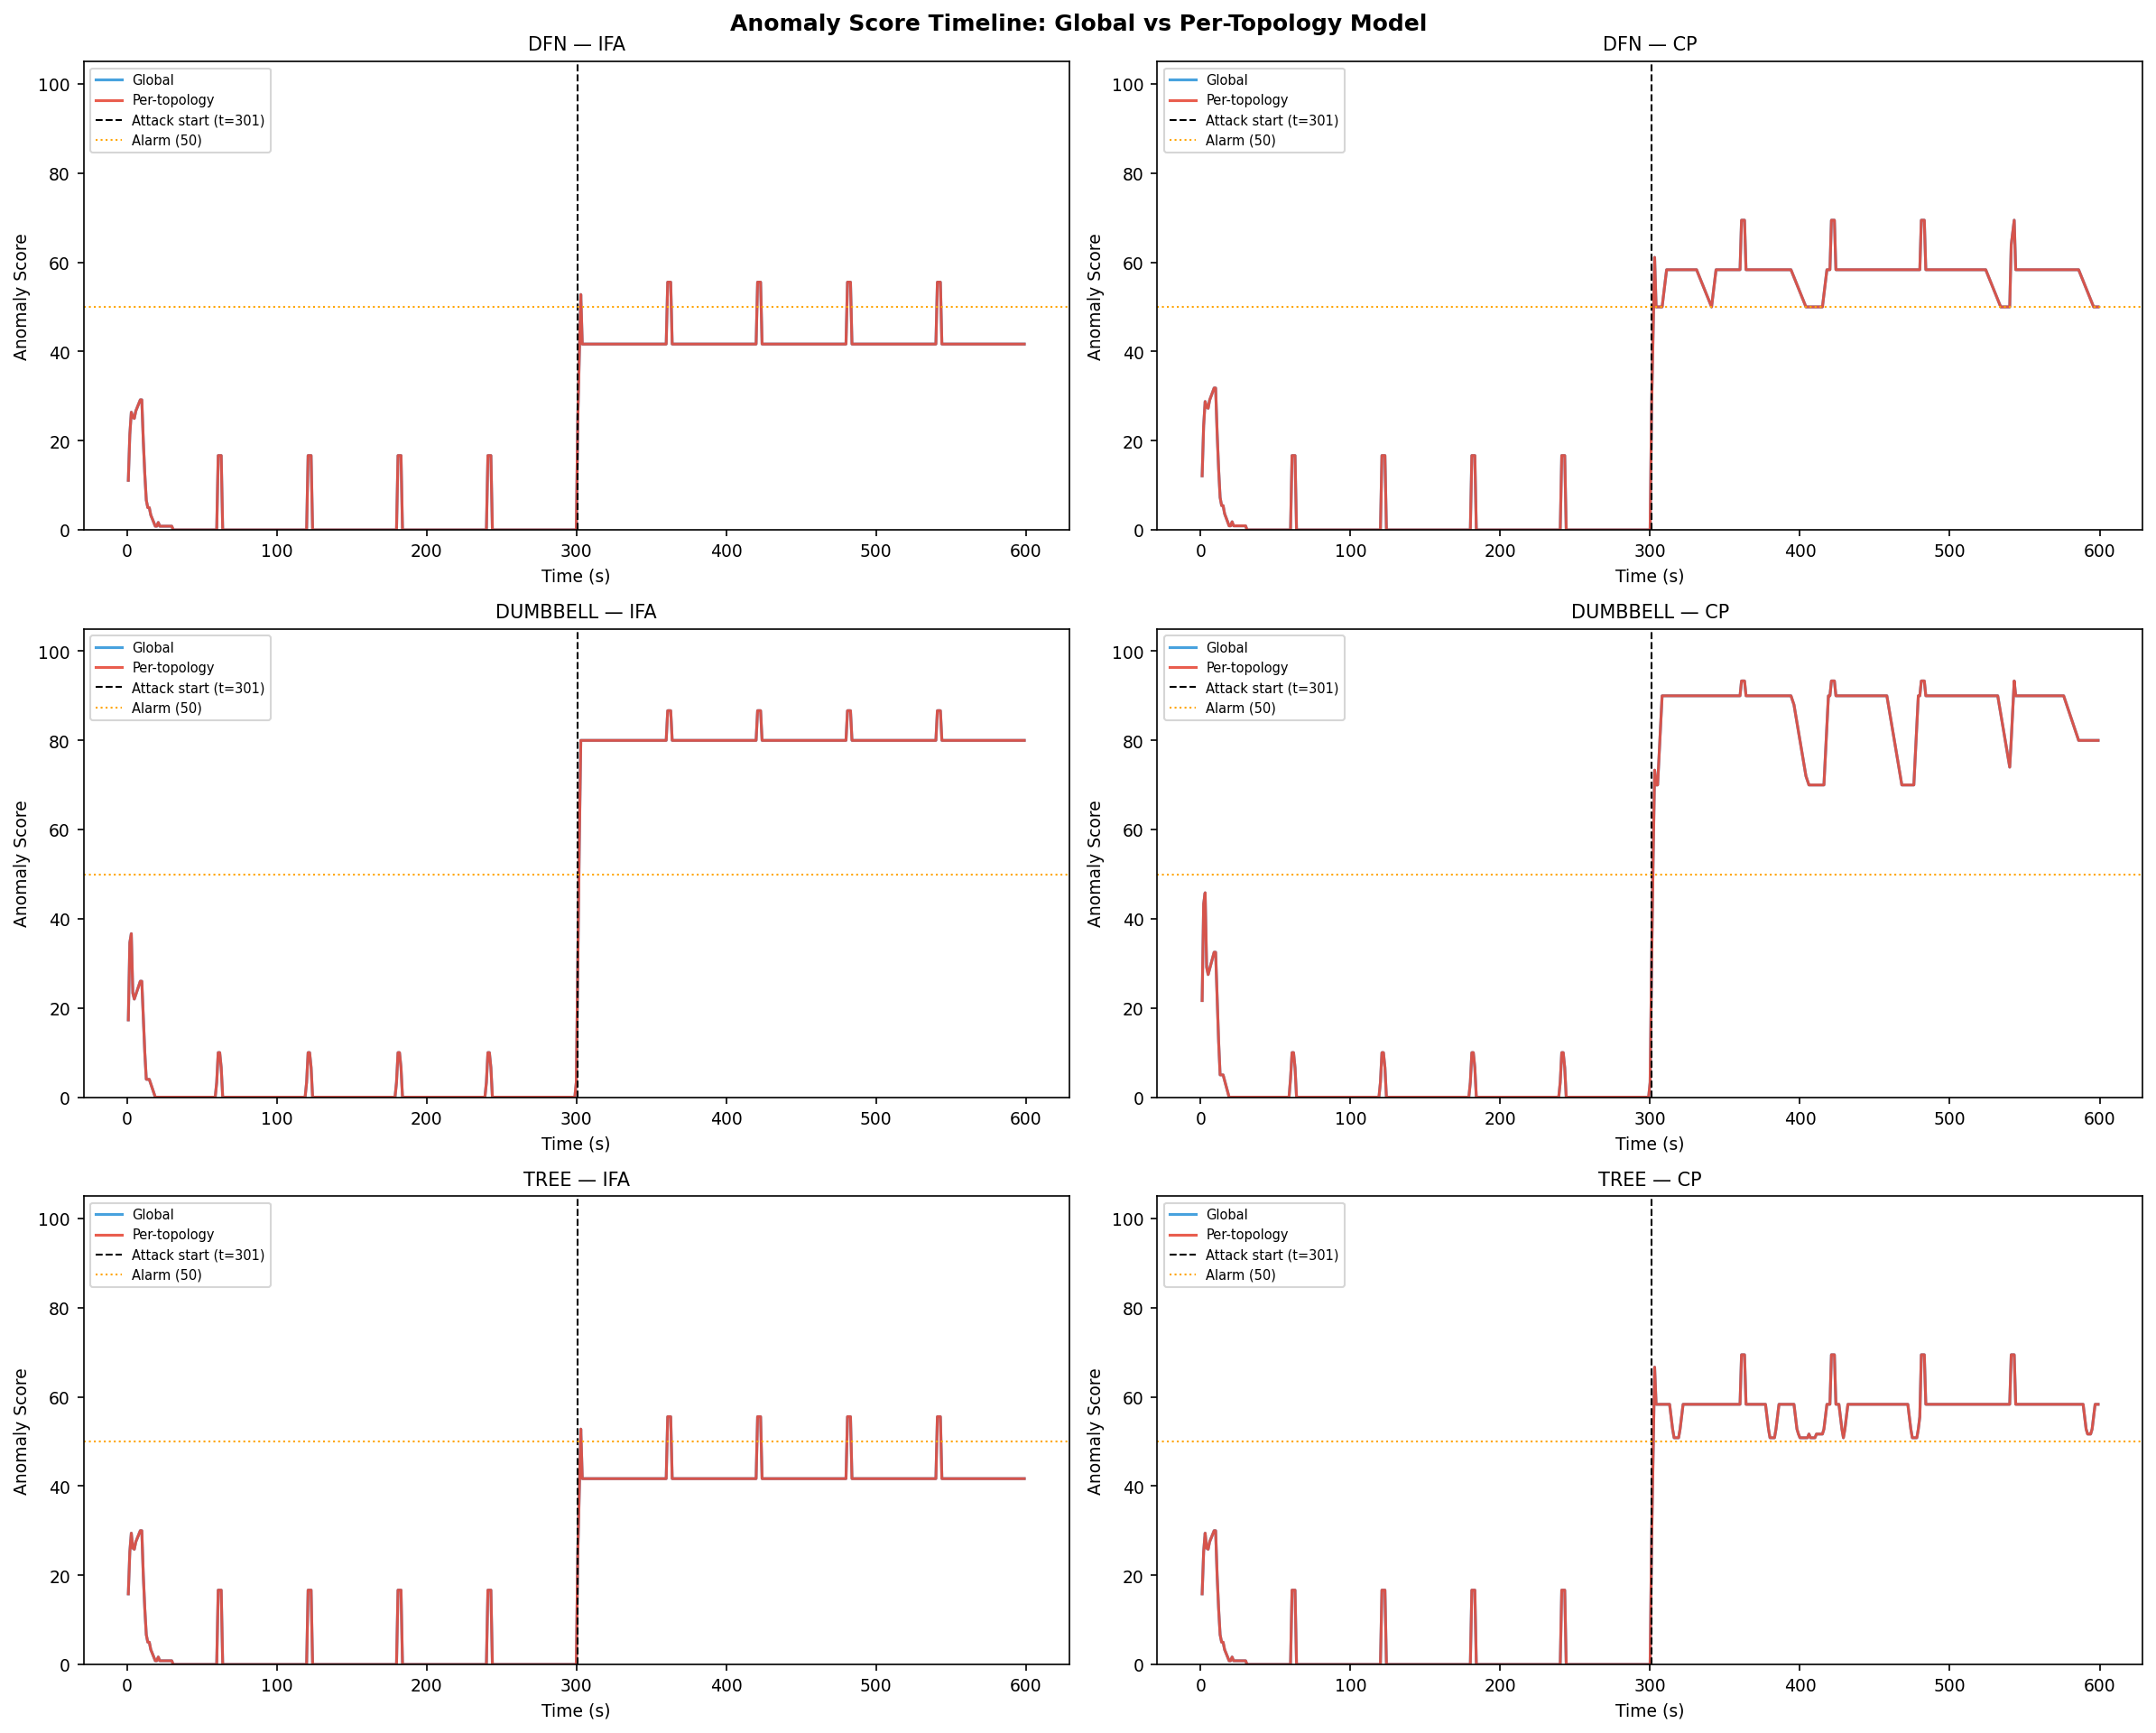

Saved fig_timeseries_comparison.png


In [12]:
fig, axes = plt.subplots(3, 2, figsize=(16, 13))
fig.suptitle("Anomaly Score Timeline: Global vs Per-Topology Model",
             fontsize=12, fontweight="bold")

for row, topo in enumerate(TOPOLOGIES):
    for col, attack in enumerate(["ifa", "cp"]):
        ax = axes[row][col]

        g_ts = full_scored[
            (full_scored["topology"]==topo) &
            (full_scored["scenario"]==attack)
        ].groupby("Time")["anomaly_score"].mean()

        p_ts = full_pertopo[
            (full_pertopo["topology"]==topo) &
            (full_pertopo["scenario"]==attack)
        ].groupby("Time")["anomaly_score"].mean()

        ax.plot(g_ts.index, g_ts.values,
                color="#3498db", linewidth=1.5,
                label="Global", alpha=0.9)
        ax.plot(p_ts.index, p_ts.values,
                color="#e74c3c", linewidth=1.5,
                label="Per-topology", alpha=0.9)
        ax.axvline(ATTACK_START, color="black", linestyle="--",
                   linewidth=1.0, label=f"Attack start (t={ATTACK_START})")
        ax.axhline(ALARM_THRESHOLD, color="orange", linestyle=":",
                   linewidth=1.0, label=f"Alarm ({ALARM_THRESHOLD})")

        ax.set_title(f"{topo.upper()} — {attack.upper()}", fontsize=10)
        ax.set_ylim(0, 105)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Anomaly Score")
        ax.legend(fontsize=7, loc="upper left")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_timeseries_comparison.png", bbox_inches="tight")
plt.show()
print("Saved fig_timeseries_comparison.png")

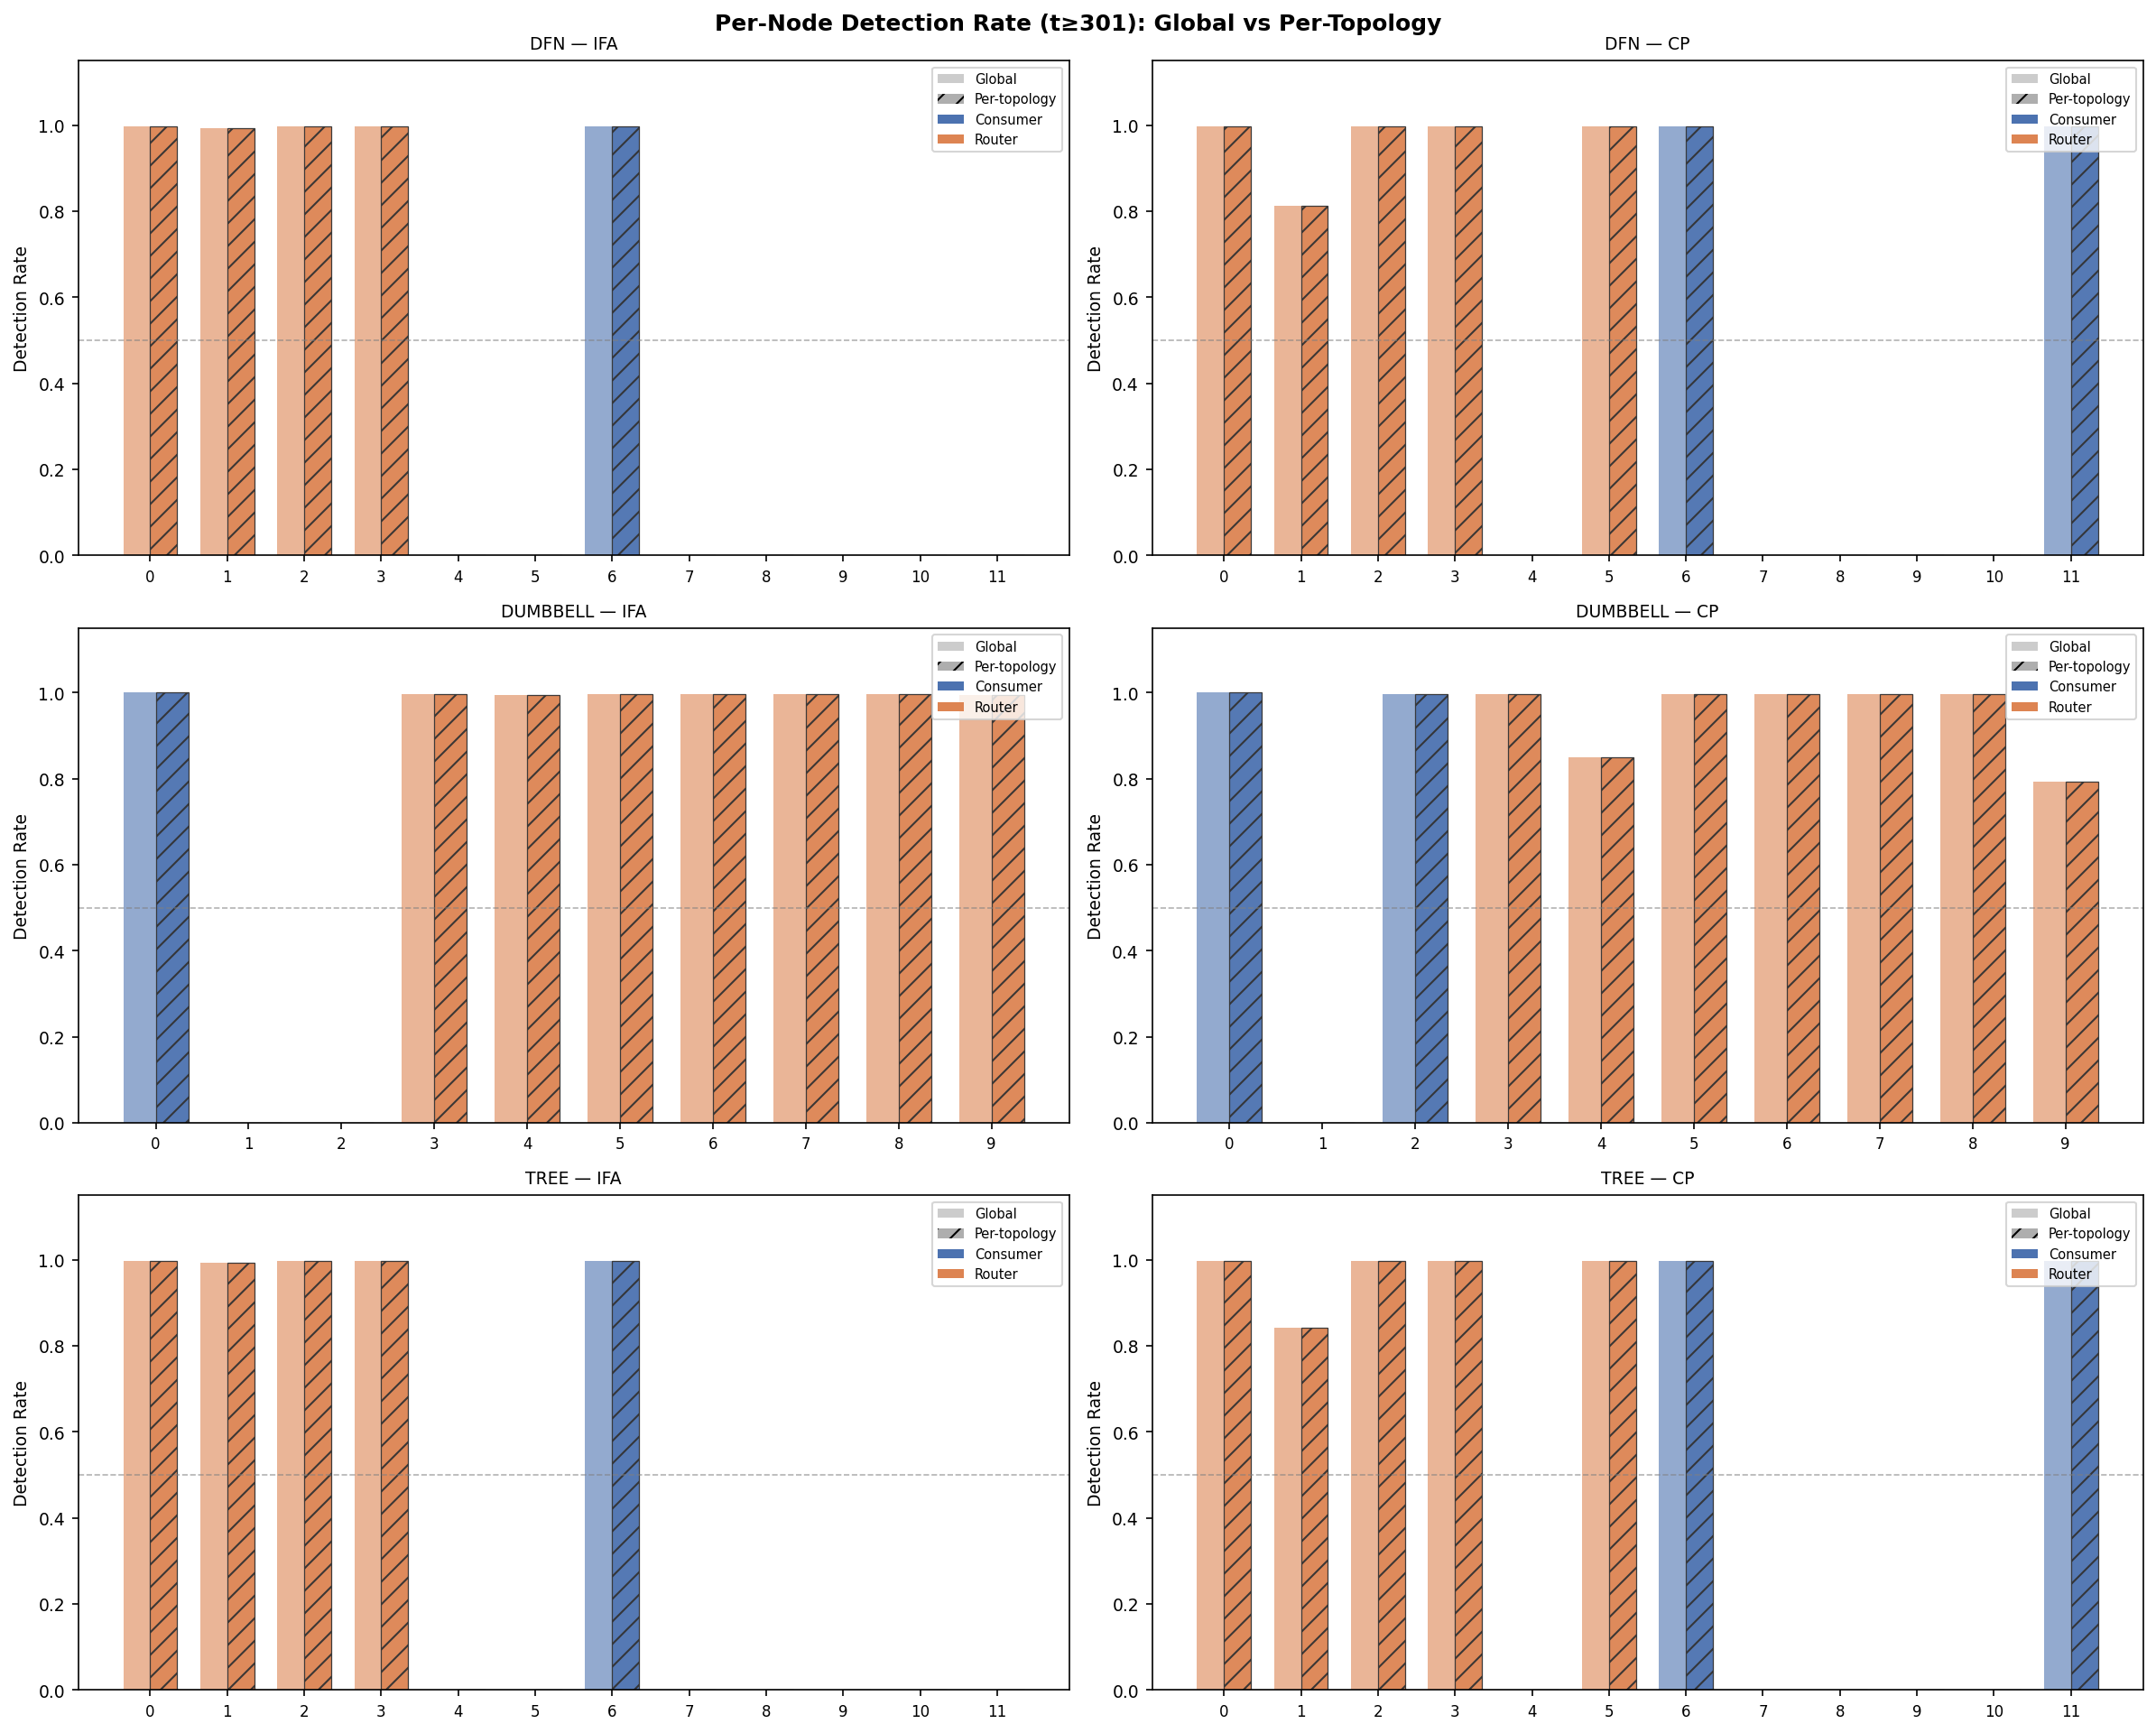

Saved fig_pernode_detection_comparison.png


In [13]:
def pernode_det_rate(scored_df, topo, attack, threshold=ALARM_THRESHOLD):
    grp = scored_df[
        (scored_df["topology"]==topo) &
        (scored_df["scenario"]==attack) &
        (scored_df["Time"] >= ATTACK_START)
    ]
    return grp.groupby("Node").apply(
        lambda x: (x["anomaly_score"] > threshold).mean()
    )

fig, axes = plt.subplots(3, 2, figsize=(16, 13))
fig.suptitle("Per-Node Detection Rate (t≥301): Global vs Per-Topology",
             fontsize=12, fontweight="bold")

for row, topo in enumerate(TOPOLOGIES):
    nodes  = sorted(full[full["topology"]==topo]["Node"].unique())
    roles  = full[full["topology"]==topo].groupby("Node")["role"].first()
    x      = np.arange(len(nodes))
    width  = 0.35

    for col, attack in enumerate(["ifa", "cp"]):
        ax     = axes[row][col]
        g_r    = pernode_det_rate(full_scored,  topo, attack)
        p_r    = pernode_det_rate(full_pertopo, topo, attack)
        colors = [ROLE_COLORS[roles[n]] for n in nodes]

        ax.bar(x - width/2,
               [g_r.get(n, 0) for n in nodes],
               width, color=colors, alpha=0.6,
               edgecolor="none", label="Global")
        ax.bar(x + width/2,
               [p_r.get(n, 0) for n in nodes],
               width, color=colors, alpha=0.95,
               edgecolor="#333", linewidth=0.6,
               hatch="//", label="Per-topology")

        ax.axhline(0.5, color="gray", linestyle="--",
                   linewidth=0.8, alpha=0.6)
        ax.set_xticks(x)
        ax.set_xticklabels(nodes, fontsize=8)
        ax.set_ylim(0, 1.15)
        ax.set_ylabel("Detection Rate")
        ax.set_title(f"{topo.upper()} — {attack.upper()}", fontsize=9)
        ax.legend(handles=[
            Patch(facecolor="#aaa", alpha=0.6,  label="Global"),
            Patch(facecolor="#aaa", alpha=0.95,
                  hatch="//", label="Per-topology"),
            Patch(facecolor=ROLE_COLORS["consumer"], label="Consumer"),
            Patch(facecolor=ROLE_COLORS["router"],   label="Router"),
        ], fontsize=7, loc="upper right")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_pernode_detection_comparison.png",
            bbox_inches="tight")
plt.show()
print("Saved fig_pernode_detection_comparison.png")

In [14]:
full_scored.to_csv(PROCESSED_DIR / "full_scored_global.csv", index=False)
full_pertopo.to_csv(PROCESSED_DIR / "full_scored_pertopo.csv", index=False)
print("Saved full_scored_global.csv")
print("Saved full_scored_pertopo.csv")

print("\n" + "="*75)
print("DETECTION SUMMARY — Temporal Lift (post - pre attack start)")
print("="*75)
print(f"{'Topology-Attack':<20} {'G pre':>7} {'G post':>8} "
      f"{'PT pre':>8} {'PT post':>9} {'G lift':>7} {'PT lift':>8}")
print("-"*75)

for topo in TOPOLOGIES:
    for attack in ["ifa", "cp"]:
        g = full_scored[
            (full_scored["topology"]==topo) &
            (full_scored["scenario"]==attack)]
        p = full_pertopo[
            (full_pertopo["topology"]==topo) &
            (full_pertopo["scenario"]==attack)]

        g_pre  = g[g["Time"] <  ATTACK_START]["anomaly_score"].mean()
        g_post = g[g["Time"] >= ATTACK_START]["anomaly_score"].mean()
        p_pre  = p[p["Time"] <  ATTACK_START]["anomaly_score"].mean()
        p_post = p[p["Time"] >= ATTACK_START]["anomaly_score"].mean()

        print(f"{topo}-{attack:<15} "
              f"{g_pre:>7.1f} {g_post:>8.1f} "
              f"{p_pre:>8.1f} {p_post:>9.1f} "
              f"{g_post-g_pre:>7.1f} {p_post-p_pre:>8.1f}")

print("\n" + "="*75)
print("METHOD: Dual per-node static baseline z-score detector")
print(f"  IFA detector : features={IFA_FEATURES}")
print(f"                 directions={IFA_DIRECTIONS}")
print(f"                 z>{IFA_Z_THRESH}, persist={IFA_PERSIST} steps")
print(f"  CP  detector : features={CP_FEATURES}")
print(f"                 directions={CP_DIRECTIONS}")
print(f"                 z>{CP_Z_THRESH}, {CP_PERSIST_FRAC*100:.0f}% of {CP_WINDOW} steps")
print(f"  Combined     : max(IFA score, CP score)")
print(f"  Baseline     : pure normal scenario, first {BASELINE_WINDOW}s")
print(f"  Alarm        : anomaly_score > {ALARM_THRESHOLD}")
print(f"  Attack start : t >= {ATTACK_START}")
print("="*75)

Saved full_scored_global.csv
Saved full_scored_pertopo.csv

DETECTION SUMMARY — Temporal Lift (post - pre attack start)
Topology-Attack        G pre   G post   PT pre   PT post  G lift  PT lift
---------------------------------------------------------------------------
dfn-ifa                 1.7     42.2      1.7      42.2    40.5     40.5
dfn-cp                  1.8     57.2      1.8      57.2    55.5     55.5
dumbbell-ifa                 1.4     80.0      1.4      80.0    78.6     78.6
dumbbell-cp                  1.5     86.5      1.5      86.5    85.0     85.0
tree-ifa                 1.8     42.2      1.8      42.2    40.4     40.4
tree-cp                  1.8     57.5      1.8      57.5    55.8     55.8

METHOD: Dual per-node static baseline z-score detector
  IFA detector : features=['satisfaction_ratio', 'timeout_ratio', 'InInterests']
                 directions={'satisfaction_ratio': 'down', 'timeout_ratio': 'up', 'InInterests': 'up'}
                 z>2.5, persist=3 steps
